### Try to repeat clustering, but only on proteobacteria (group 1 variants)

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mgsa.helpers import plot
from mgsa.io import get_data
 



### Collect data, same as before

In [104]:
KO = 'K00370'
map = '09'
Drug = 'None'

complete_ids = pd.read_csv(f'../out/aaseqs/{KO}/long_complete_orf_ids.txt', header = None)
complete_ids = complete_ids.values
print(complete_ids.shape, complete_ids.dtype)

all_ids = pd.read_csv(f'../out/orf_ids/cluster_ids_{map}_{KO}.tsv', sep = '\t', header=None)

map = pd.read_csv(f'../out/aaseqs/{KO}/incomplete_to_complete_seq_mapping.tsv', sep = '\t')
map = map.values
print(map[:,1].shape, map[:,1].dtype)
print(map)

T0data = np.zeros((len(complete_ids), 20))
T9data = np.zeros((len(complete_ids), 10, 11))

for i, id in enumerate(complete_ids):
    got_data = get_data(id, drug = Drug, KO=KO)
    T0data[i] += got_data[0]
    T9data[i] += got_data[1]

print(T9data[:,:,1].shape)

for i, id in enumerate(map[:,0]):
    complete_id = map[i, 1]
    idx = np.where(complete_ids == complete_id)[0][0]
    got_data = get_data(id, drug = Drug)
    T0data[idx] += got_data[0]
    T9data[idx] += got_data[1]






(57, 1) object
(451,) object
[['Soil11.scaffold_669406189_c1_1' 'Soil9.scaffold_209032411_c1_3'
  5.449392712550607]
 ['Soil11.scaffold_168782194_c1_1' 'Soil9.scaffold_209032411_c1_3'
  4.704142011834319]
 ['Soil11.scaffold_603781636_c1_1' 'Soil15.scaffold_116822102_c1_19'
  4.966360856269113]
 ...
 ['T0.scaffold_685359621_c1_1' 'Soil6.scaffold_312871021_c1_4'
  4.787878787878788]
 ['T0.scaffold_925671294_c1_1' 'Soil17.scaffold_274056314_c1_61'
  4.8262108262108265]
 ['T0.scaffold_409096425_c1_1' 'Soil5.scaffold_183283646_c1_24'
  5.014767932489452]]
(57, 10)


In [105]:

from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()

data_abs = T0data
T0data = T0data / T0data.sum(axis = 1, keepdims=True)
T0data = np.nan_to_num(T0data, nan = 0)

data = T0data 
for i in range(10):
    T9temp = T9data[:,i,:]
    data_abs = np.hstack((data_abs, T9temp))
    T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)
    T9temp = np.nan_to_num(T9temp, nan = 0)
    data = np.hstack((data, T9temp))
    

pairwise_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')
pairwise_data = scaler.fit_transform(pairwise_data)
#data = np.hstack((data, pairwise_data))

#now select group 1 indices


indices = []
line_number = 0

with open('../out/groups/assignments_K00370_v2.tsv', 'r') as file:
    for line in file:
        line = line.strip()
        if line.endswith(' 1'):
            indices.append(line_number)
        line_number += 1

print("Line indices ending with 1:")
print(indices)
print(f"\nTotal: {len(indices)} rows")

data = data[indices]
data_abs = data_abs[indices]
pairwise_data = pairwise_data[indices]
pairwise_data = pairwise_data[:,indices]
data_abs = np.hstack((data_abs, pairwise_data))

data = np.hstack((data, pairwise_data))

a = 0.5
weights = np.concatenate([
    np.full(20, a**2/np.sqrt(130)),    
    np.full(110, a**2/np.sqrt(130)) ,
    np.full(18, (np.sqrt(1 - a**2))/np.sqrt(57))
])

weighted_data = data * weights 

Line indices ending with 1:
[1, 3, 4, 5, 6, 11, 14, 15, 19, 21, 25, 26, 28, 37, 44, 45, 53, 54]

Total: 18 rows


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_62097/3783555124.py:6: RuntimeWarning: invalid value encountered in divide
  T0data = T0data / T0data.sum(axis = 1, keepdims=True)
/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_62097/3783555124.py:13: RuntimeWarning: invalid value encountered in divide
  T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)


[3, 14, 0, 4, 9, 2, 8, 17, 7, 5, 16, 13, 11, 10, 15, 1, 6, 12]


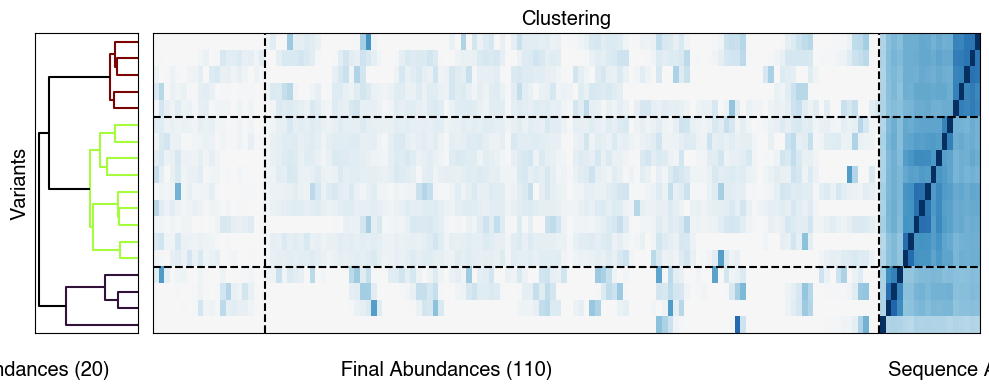

In [106]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex


Z = linkage(weighted_data, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(data, metric='euclidean'))

n_clusters = 3
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
    

#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [0.5, 4]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(data)

rearranged_data = data[leaf_indices]
col_leaf_indices = leaf_indices+130*np.ones(18, dtype = int)
rearranged_data[:, 130:148] = rearranged_data[:, col_leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdBu',
                interpolation='nearest', origin='lower', vmin = -1, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
for b in boundaries:
    ax2.axhline(b + 0.5, color='black', linestyle='--')
    
ax2.axvline(19.5, color='black', linestyle='--')
ax2.axvline(129.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_title('Clustering', fontname='Helvetica', fontsize = 'x-large')
ax2.set_xlabel('\n Initial Abundances (20) \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t        Final Abundances (110)   \t \t \t \t \t  \t \t \t \t  \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t Sequence Alignments (18) \t \t \t \t \t \t \t \t \t \t', fontname='Helvetica', fontsize = 'x-large')

#ax2.set_ylabel('Variants', fontname='Helvetica', fontsize='x-large')

ax2.set_yticks([])
ax2.set_yticks([])
plt.tight_layout()

print(leaf_indices)
    
plt.show()

(18, 148)
(18, 148)
[ 3 12]


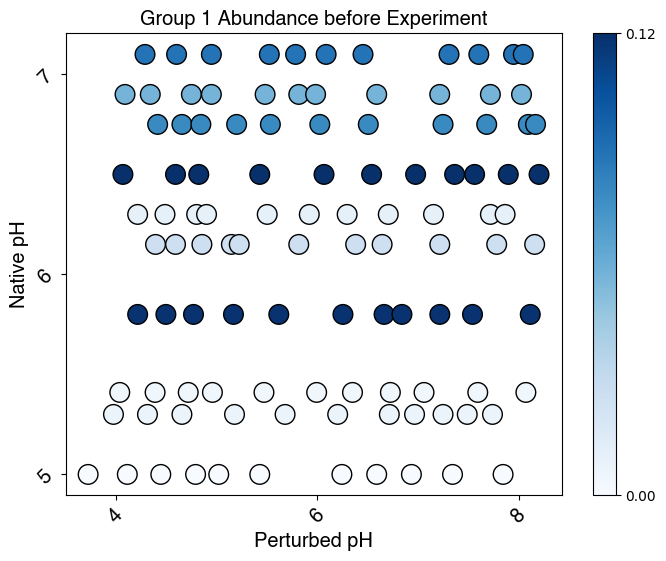

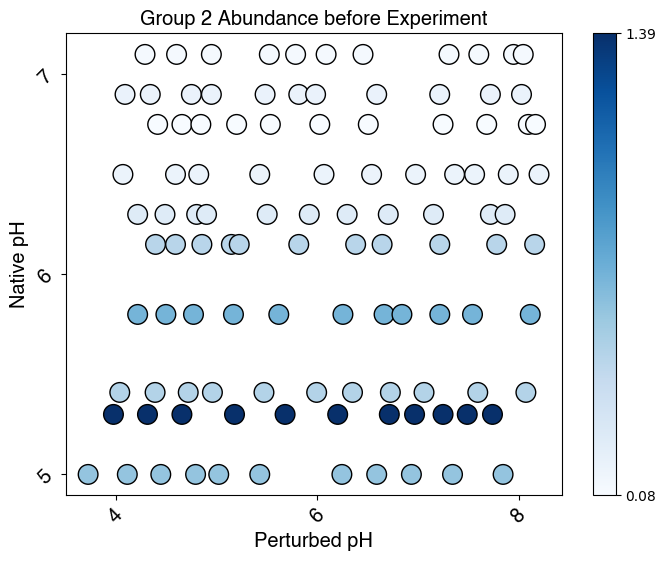

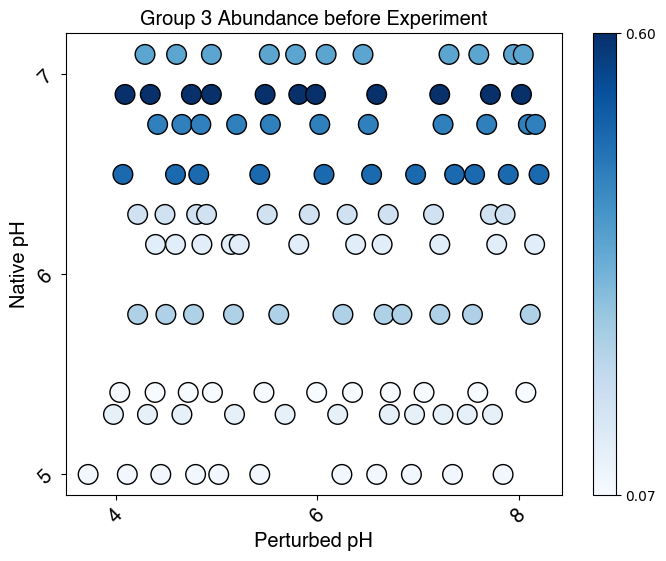

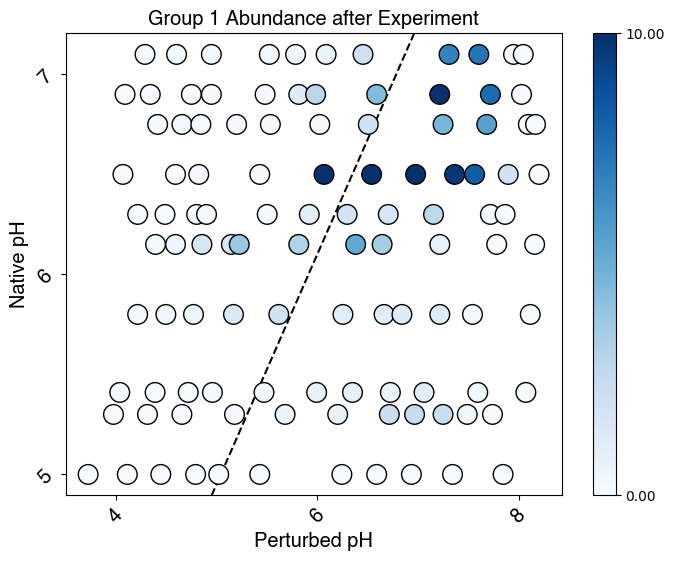

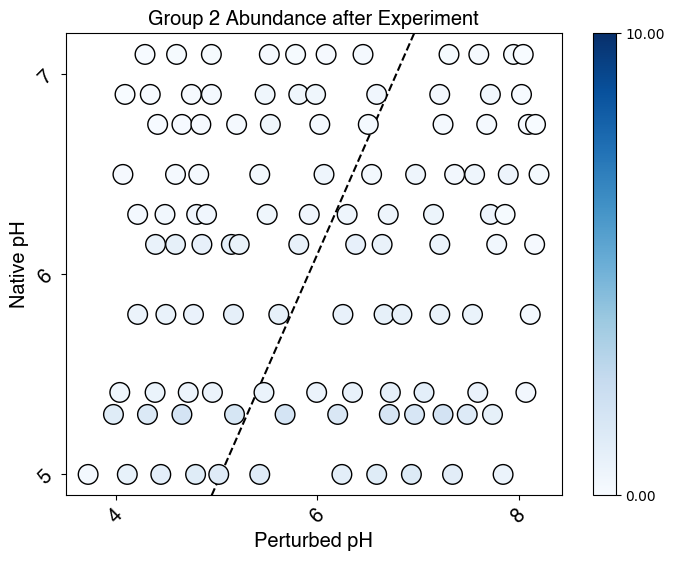

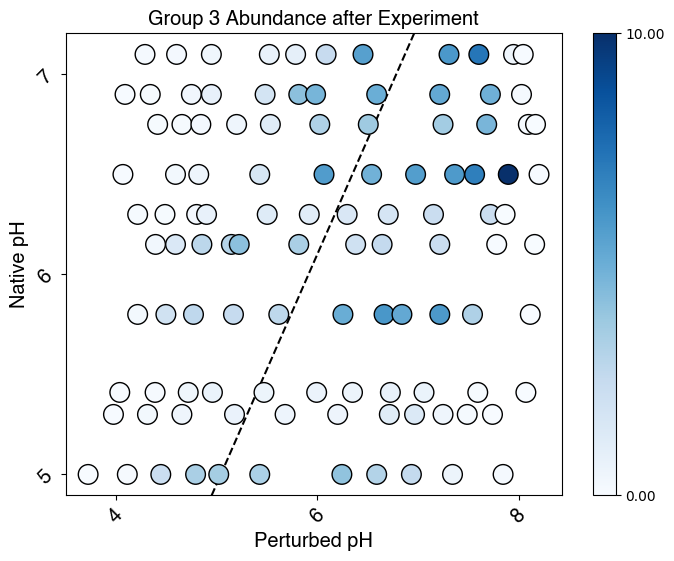

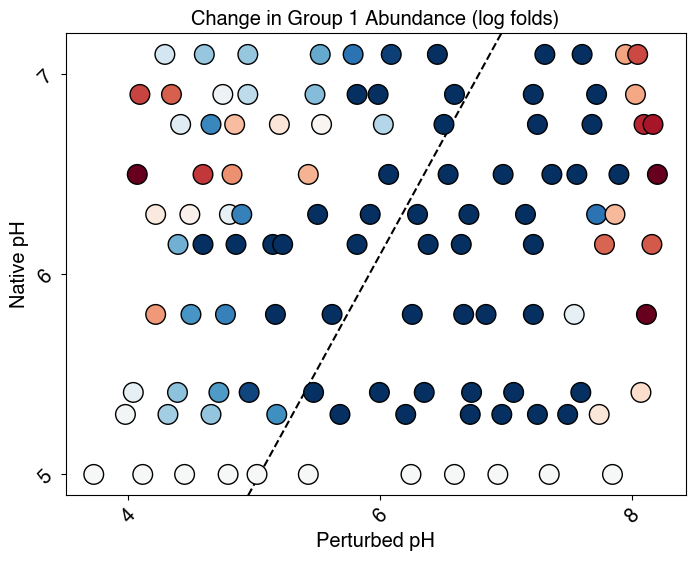

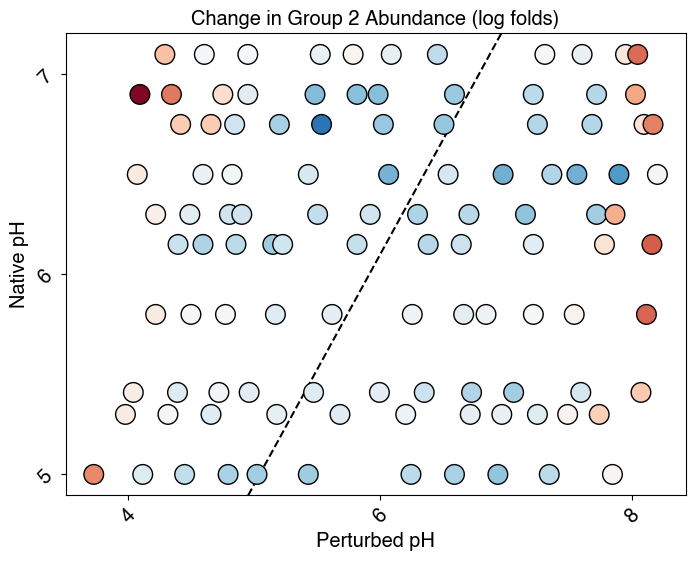

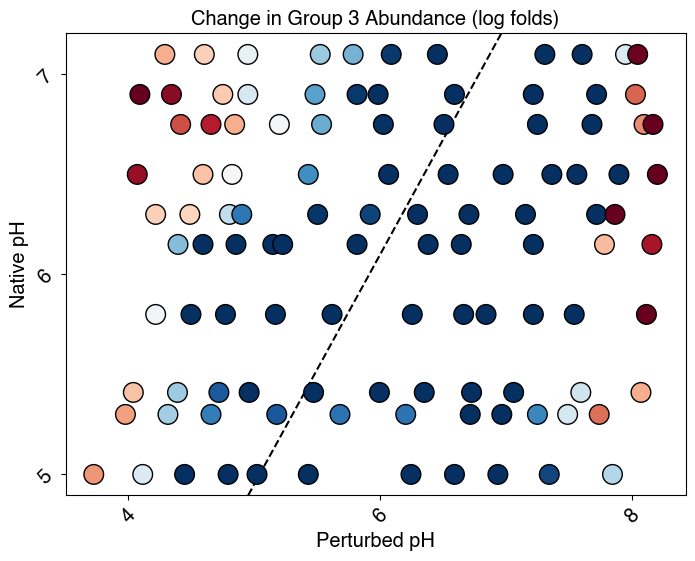

In [107]:
new_data = data_abs[leaf_indices]

print(data.shape)
print(new_data.shape)
print(boundaries)
from mgsa.helpers import plot

groups = np.zeros((n_clusters,148))

for i, datum in enumerate(new_data):
    for j in range(1, n_clusters-1):
        if i > boundaries[j - 1] and i < boundaries[j]:
            groups[j] += datum
    if i < boundaries[0]:
        groups[0] += datum
    elif i > boundaries[n_clusters-2]:
        groups[n_clusters-1] += datum




selected = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]

#T0
groups_T0 = [np.zeros((10, 11)) for _ in range(n_clusters)]

for i in range(10): #native pH
    for j in range(n_clusters):
        groups_T0[j][i] = groups[j][selected][i]
        
for j in range(n_clusters):
    plot(groups_T0[j], f'Group {j+1} Abundance before Experiment')

#T9
groups_T9 = [np.zeros((10, 11)) for _ in range(n_clusters)]

for i in range(10): #native pH
    for j in range(11): #perturbed pH
        for k in range(n_clusters):
            groups_T9[k][i][j] = groups[k][20 + 11*i + j]
            
for i in range(n_clusters):
    plot(groups_T9[i],  f'Group {i+1} Abundance after Experiment', vmin = 0, vmax = 10, include_line=True)
        
for i in range(n_clusters):
    plot(np.log((groups_T9[i] + 0.01*np.ones_like(groups_T9[i])) /  (groups_T0[i]+ 0.01 * np.ones_like(groups_T0[i]))), f'Change in Group {i+1} Abundance (log folds)', vmin = -2, vmax = 2, cmap = 'RdBu', c_bar = False, include_line = True)
    #plot(groups_T9[i] - groups_T0[i], 'change subtraction', cmap = 'RdBu', vmin = -1, vmax = 1)

#change



### Create a new fasta with proteo sequences, labels with group IDs

In [108]:
#subset the fasta file to only contain proteobacteria

from Bio import SeqIO

print(indices)
input_fasta = "../out/aaseqs/K00370/long_complete_aa_seqs.fasta"

#read seqs
all_seqs = list(SeqIO.parse(input_fasta, "fasta"))


#subset
proteo_seqs = [all_seqs[i] for i in indices]
proteo_ids = [seq.id for seq in proteo_seqs]

#output
SeqIO.write(proteo_seqs, "../out/aaseqs/K00370/long_complete_proteobacteria.fasta", "fasta")

print(f"Selected {len(proteo_seqs)} sequences out of {len(all_seqs)} total")

#Also, write the IDs to a text file
with open("../out/aaseqs/K00370/proteo_orf_ids.txt", "w") as f:
    for seq_id in proteo_ids:
        f.write(f"{seq_id}\n")

print(f"Created files with {len(proteo_seqs)} sequences/IDs")

# Next, make a file assigning clusters
orf_list = pd.read_csv('../out/aaseqs/K00370/proteo_orf_ids.txt', header=None)
orf_list = orf_list.values
orf_list = [orf[0] for orf in orf_list]

proteo_clusters = list(zip(orf_list, clusters))

with open("../out/groups/assignments_K00370_proteo.tsv", 'w') as f:
    for orf, cluster in proteo_clusters:
        f.write(f"{orf} {cluster}\n")



[1, 3, 4, 5, 6, 11, 14, 15, 19, 21, 25, 26, 28, 37, 44, 45, 53, 54]
Selected 18 sequences out of 57 total
Created files with 18 sequences/IDs


### Next, identify the classes associated with these three groups.

In [109]:
## First Collect taxid's for each of these 

# Read the file and find Bacteroidota taxids
alpha_taxids = []
beta_taxids = []
gamma_taxids = []
delta_taxids = []

with open('../data/whole_genomes/taxids_TIGR01580_metadata.tsv', 'r') as file:
    headers = file.readline().strip().split('\t')
    
    # Find the index of 'phylum' and 'taxid' columns
    class_idx = headers.index('class')
    taxid_idx = headers.index('taxid')
    
    for line in file:
        fields = line.strip().split('\t')
        if fields[class_idx] == 'Alphaproteobacteria':
            alpha_taxids.append(fields[taxid_idx])
        if fields[class_idx] == 'Betaproteobacteria':
            beta_taxids.append(fields[taxid_idx])
        if fields[class_idx] == 'Gammaproteobacteria':
            gamma_taxids.append(fields[taxid_idx])
        if fields[class_idx] == 'Deltaproteobacteria':
            delta_taxids.append(fields[taxid_idx])

print(f"Found {len(alpha_taxids)} rows with class alpha")
print("TaxIDs:", alpha_taxids)
print(f"Found {len(beta_taxids)} rows with class beta")
print("TaxIDs:", beta_taxids)
print(f"Found {len(gamma_taxids)} rows with class gamma")
print("TaxIDs:", gamma_taxids)
print(f"Found {len(delta_taxids)} rows with class delta")
print("TaxIDs:", delta_taxids)




Found 548 rows with class alpha
TaxIDs: ['82', '87', '235', '280', '281', '293', '529', '912', '913', '1035', '1044', '1062', '1078', '1087', '28214', '29421', '29448', '29459', '34002', '34004', '34006', '34007', '34009', '35804', '35805', '53463', '53501', '60890', '65735', '69279', '69665', '69670', '69974', '74033', '74329', '82367', '83219', '89184', '93369', '93980', '94626', '94627', '104099', '104100', '104102', '113574', '121719', '121821', '135740', '142585', '144026', '147645', '171437', '178900', '178901', '182270', '184748', '187304', '189873', '196587', '198092', '204722', '211460', '220697', '224914', '227605', '228405', '245188', '255457', '258256', '260084', '262698', '267128', '281252', '282197', '287478', '287609', '293089', '309857', '314253', '314262', '318586', '321339', '323097', '323098', '331696', '335286', '335406', '349163', '359391', '361183', '363754', '364200', '364297', '365340', '366602', '374515', '375451', '388739', '392610', '394221', '395965', '40488

In [110]:
from Bio import SeqIO

# Create sets from the taxid lists
alpha_set = set(alpha_taxids)
beta_set = set(beta_taxids)
gamma_set = set(gamma_taxids)
delta_set = set(delta_taxids)

# Store sequences per class
alpha_seqs = []
beta_seqs = []
gamma_seqs = []
delta_seqs = []

input_fasta = "../data/whole_genomes/TIGR01580.fasta"  

for record in SeqIO.parse(input_fasta, "fasta"):
    header = record.description
    if 'taxID:' in header:
        taxid = header.split('taxID:')[-1].split()[0]
        
        # Check each proteobacteria class
        if taxid in alpha_set:
            alpha_seqs.append(record)
        elif taxid in beta_set:
            beta_seqs.append(record)
        elif taxid in gamma_set:
            gamma_seqs.append(record)
        elif taxid in delta_set:
            delta_seqs.append(record)

# Write each class to separate FASTA files
SeqIO.write(alpha_seqs, "../data/whole_genomes/Alphaproteobacteria.fasta", "fasta")
SeqIO.write(beta_seqs, "../data/whole_genomes/Betaproteobacteria.fasta", "fasta")
SeqIO.write(gamma_seqs, "../data/whole_genomes/Gammaproteobacteria.fasta", "fasta")
SeqIO.write(delta_seqs, "../data/whole_genomes/Deltaproteobacteria.fasta", "fasta")

print(f"Alphaproteobacteria: {len(alpha_seqs)} sequences")
print(f"Betaproteobacteria: {len(beta_seqs)} sequences")
print(f"Gammaproteobacteria: {len(gamma_seqs)} sequences")
print(f"Deltaproteobacteria: {len(delta_seqs)} sequences")

from Bio import SeqIO
import random

num_reps = 500

def get_reps(sequences, num_representatives=5):
    if len(sequences) <= num_representatives:
        return sequences
    
    sequences_by_taxid = {}
    for record in sequences:
        header = record.description
        if 'taxID:' in header:
            taxid = header.split('taxID:')[-1].split()[0]
            if taxid not in sequences_by_taxid:
                sequences_by_taxid[taxid] = []
            sequences_by_taxid[taxid].append(record)
    

    unique_taxid_seqs = []
    for taxid, seqs in sequences_by_taxid.items():
        unique_taxid_seqs.append(random.choice(seqs))  # Pick one random sequence per taxid
    

    if len(unique_taxid_seqs) >= num_representatives:
        return random.sample(unique_taxid_seqs, num_representatives)
    else:
        return random.sample(sequences, min(num_representatives, len(sequences)))


alpha_reps = get_reps(alpha_seqs, num_reps)
beta_reps = get_reps(beta_seqs, num_reps)
gamma_reps = get_reps(gamma_seqs, num_reps)
delta_reps = get_reps(delta_seqs, num_reps)


SeqIO.write(alpha_reps, "../data/whole_genomes/Alphaproteobacteria_representatives.fasta", "fasta")
SeqIO.write(beta_reps, "../data/whole_genomes/Betaproteobacteria_representatives.fasta", "fasta")
SeqIO.write(gamma_reps, "../data/whole_genomes/Gammaproteobacteria_representatives.fasta", "fasta")
SeqIO.write(delta_reps, "../data/whole_genomes/Deltaproteobacteria_representatives.fasta", "fasta")

print("Representative sequences selected:")
print(f"Alphaproteobacteria: {len(alpha_reps)} representatives")
print(f"Betaproteobacteria: {len(beta_reps)} representatives")
print(f"Gammaproteobacteria: {len(gamma_reps)} representatives")
print(f"Deltaproteobacteria: {len(delta_reps)} representatives")

Alphaproteobacteria: 730 sequences
Betaproteobacteria: 973 sequences
Gammaproteobacteria: 3875 sequences
Deltaproteobacteria: 16 sequences
Representative sequences selected:
Alphaproteobacteria: 500 representatives
Betaproteobacteria: 500 representatives
Gammaproteobacteria: 500 representatives
Deltaproteobacteria: 16 representatives


### Now perform the alignment

In [111]:
from Bio import SeqIO
from Bio import Align
from Bio.Align import substitution_matrices
import pandas as pd


query_seqs = list(SeqIO.parse("../out/aaseqs/K00370/long_complete_proteobacteria.fasta", "fasta"))


Class = ['Alphaproteobacteria', 'Betaproteobacteria', 'Gammaproteobacteria', 'Deltaproteobacteria']


aligner = Align.PairwiseAligner()
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.mode = 'global'  


results = []

print("Performing pairwise alignments...")

for query_seq in query_seqs:
    query_id = query_seq.id
    
    for c in Class:
        rep_file = f"../data/whole_genomes/{c}_representatives.fasta"
        try:
            rep_seqs = list(SeqIO.parse(rep_file, "fasta"))
        except FileNotFoundError:
            print(f"Warning: {rep_file} not found, skipping {c}")
            continue
        
        for i, rep_seq in enumerate(rep_seqs):
            rep_id = rep_seq.id
            
            # Perform alignment
            alignment = aligner.align(query_seq.seq, rep_seq.seq)[0]  # Take best alignment
            
            # Calculate alignment score and identity
            score = alignment.score
            alignment_length = alignment.shape[1]
            identities = sum(a == b for a, b in zip(alignment[0], alignment[1]))
            identity_percent = (identities / alignment_length) * 100
            
            results.append({
                'query_id': query_id,
                'class': c,
                'representative_id': rep_id,
                'representative_index': i + 1,
                'alignment_score': score,
                'alignment_length': alignment_length,
                'identities': identities,
                'identity_percent': identity_percent
            })
    
    print(f"Completed alignments for query {query_id}")


df_results = pd.DataFrame(results)


df_results.to_csv("../out/whole_genomes/class_alignment_scores.csv", index=False)


summary_df = df_results.groupby(['query_id', 'class']).agg({
    'alignment_score': 'mean',
    'identity_percent': 'mean'
}).reset_index()

summary_df.to_csv("../out/whole_genomes/class_alignment_summary.csv", index=False)

print("Alignment completed!")
print(f"Total alignments performed: {len(results)}")
print(f"Results saved to: class_alignment_scores.csv")
print(f"Summary saved to: class_alignment_summary.csv")

# Print some statistics
print("\nAlignment statistics per class:")
for c in Class:
    phylum_data = df_results[df_results['class'] == c]
    if len(phylum_data) > 0:
        avg_score = phylum_data['alignment_score'].mean()
        avg_identity = phylum_data['identity_percent'].mean()
        print(f"{c}: {len(phylum_data)} alignments, avg score: {avg_score:.2f}, avg identity: {avg_identity:.2f}%")

Performing pairwise alignments...
Completed alignments for query Soil11.scaffold_587233302_c1_1
Completed alignments for query Soil11.scaffold_211583530_c1_6
Completed alignments for query Soil12.scaffold_266712765_c1_2
Completed alignments for query Soil14.scaffold_576820813_c1_40
Completed alignments for query Soil14.scaffold_280216268_c1_12
Completed alignments for query Soil15.scaffold_16321085_c1_6
Completed alignments for query Soil16.scaffold_804923086_c1_3
Completed alignments for query Soil16.scaffold_313969256_c1_10
Completed alignments for query Soil17.scaffold_1202428475_c1_2
Completed alignments for query Soil17.scaffold_332687915_c1_2
Completed alignments for query Soil3.scaffold_408070428_c1_2
Completed alignments for query Soil3.scaffold_285743490_c1_2
Completed alignments for query Soil5.scaffold_215117222_c1_59
Completed alignments for query Soil5.scaffold_416434691_c1_48
Completed alignments for query Soil6.scaffold_312871021_c1_4
Completed alignments for query Soil6

In [112]:
import numpy as np

groups = pd.read_csv("../out/groups/assignments_K00370_proteo.tsv", sep = '\t', header = None).values
summary_stats = pd.read_csv("../out/whole_genomes/class_alignment_summary.csv")

#count group_sizes:
group_size = np.zeros(4)
for row in groups:
    if row[0][-1] == '1':
        group_size[0] += 1
    elif row[0][-1] == '2':
        group_size[1] += 1
    elif row[0][-1] == '3':
        group_size[2] += 1
    elif row[0][-1] == '4':
        group_size[3] += 1
        

group_assignments = {}

with open("../out/groups/assignments_K00370_proteo.tsv", "r") as f: 
    for line in f:
        line = line.strip()
        if line:  
            parts = line.split()
            if len(parts) >= 2:
                seq_id = parts[0]
                group = int(parts[1])
                group_assignments[seq_id] = group

    
class_to_number = {c: i for i, c in enumerate(Class)}

    
group_class_scores = np.zeros((4,4))

for row in summary_stats.values:
    group_class_scores[group_assignments[row[0]]-1, class_to_number[row[1]]] += row[2]/group_size[group_assignments[row[0]]-1]
    
    

    


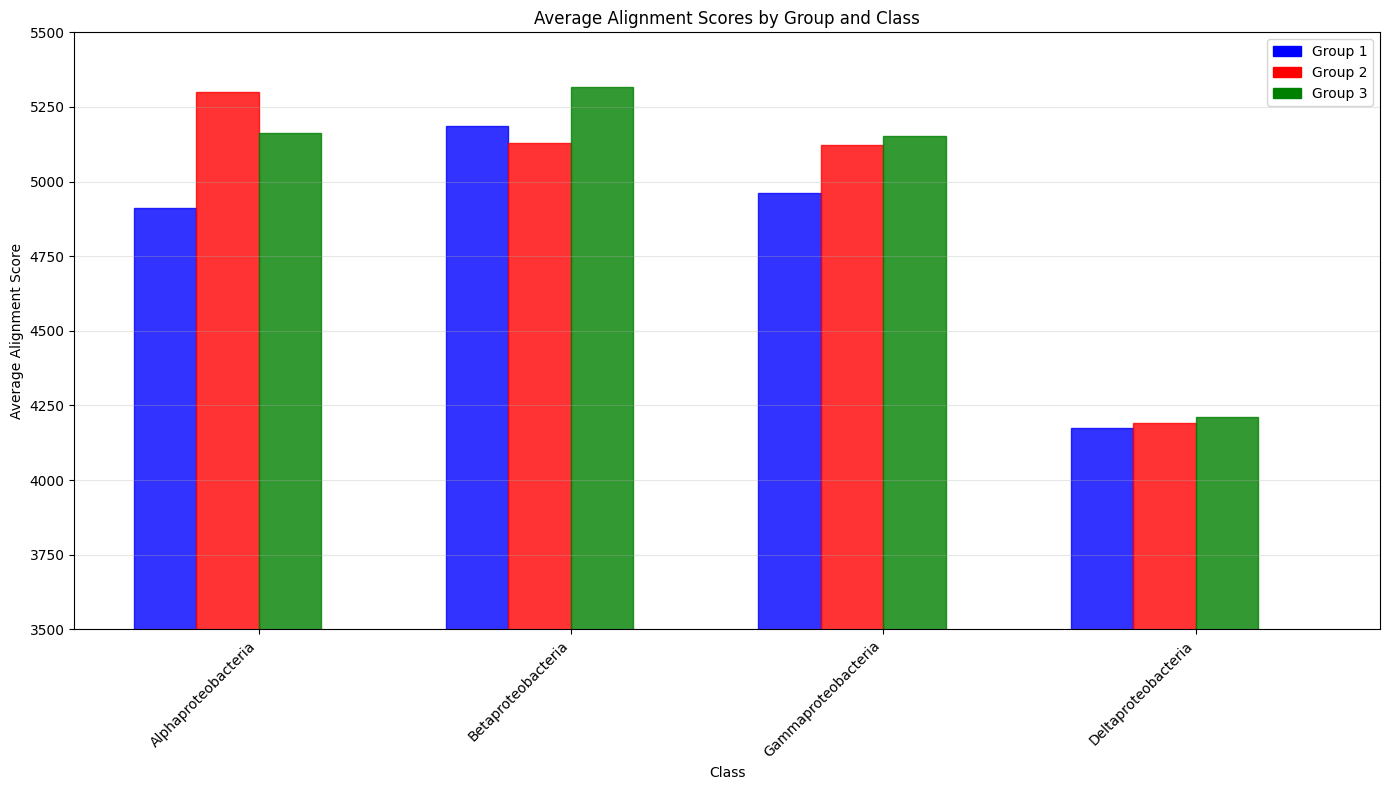

In [113]:
# Alternative: Groups clustered for each phylum
import matplotlib.pyplot as plt 


# Define colors for each group
colors = ['blue', 'red', 'green']
group_labels = ['Group 1', 'Group 2', 'Group 3']

# Set up bar positions
x = np.arange(4)  # x positions for phyla
bar_width = 0.2   # width of each bar

plt.figure(figsize=(14, 8))

for i, c in enumerate(Class):
    bar_positions = [i + j * bar_width for j in range(4)]
    scores = [group_class_scores[group][i] for group in range(4)]
    bars = plt.bar(bar_positions, scores, width=bar_width, alpha=0.8)
    for bar, color in zip(bars, colors):
        bar.set_color(color)

plt.xlabel('Class')
plt.ylabel('Average Alignment Score')
plt.title('Average Alignment Scores by Group and Class')
plt.xticks(x + bar_width * 1.5, Class, rotation=45, ha='right')
plt.legend([plt.Rectangle((0,0),1,1, color=color) for color in colors], group_labels)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.ylim(3500,5500)
plt.show()

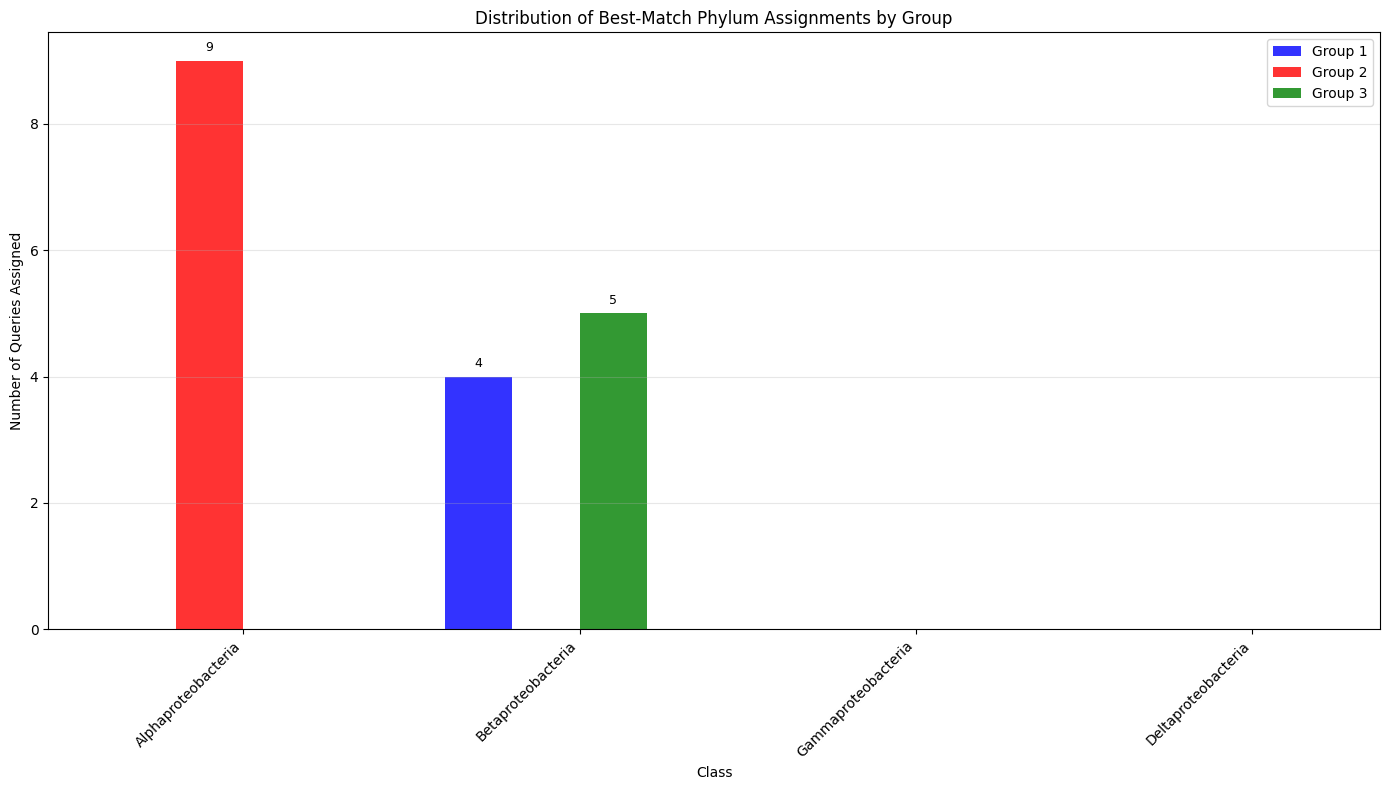

Assignment counts by phylum and group:

Alphaproteobacteria:
  Group 2: 9 queries

Betaproteobacteria:
  Group 1: 4 queries
  Group 3: 5 queries

Gammaproteobacteria:

Deltaproteobacteria:

Total queries assigned: 18.0


In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First, let's find the "best match" phylum for each query
best_matches = {}

for row in summary_stats.values:
    query_id = row[0]
    c = row[1]
    score = row[2]
    
    if query_id not in best_matches:
        best_matches[query_id] = {'class': c, 'score': score}
    else:
        if score > best_matches[query_id]['score']:
            best_matches[query_id] = {'class': c, 'score': score}

# Create a matrix to count assignments
class_assignment_counts = np.zeros((4, 4))  # 9 phyla x 4 groups

# Count assignments
for query_id, best_match in best_matches.items():
    group = group_assignments[query_id] - 1  # Convert to 0-based index
    class_idx = class_to_number[best_match['class']]
    class_assignment_counts[class_idx, group] += 1

# Create the plot
plt.figure(figsize=(14, 8))

# Define colors for each group
colors = ['blue', 'red', 'green']
group_labels = ['Group 1', 'Group 2', 'Group 3']

# Set up bar positions
x = np.arange(4)  # x positions for phyla
bar_width = 0.2   # width of each bar

# Create bars for each group
for group in range(3):
    bar_positions = x + (group - 1.5) * bar_width
    plt.bar(bar_positions, class_assignment_counts[:, group], 
            width=bar_width, color=colors[group], label=group_labels[group], alpha=0.8)

# Customize the plot
plt.xlabel('Class')
plt.ylabel('Number of Queries Assigned')
plt.title('Distribution of Best-Match Phylum Assignments by Group')
plt.xticks(x, Class, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on top of bars
for group in range(4):
    bar_positions = x + (group - 1.5) * bar_width
    for i, count in enumerate(class_assignment_counts[:, group]):
        if count > 0:  # Only label if count > 0
            plt.text(bar_positions[i], count + 0.1, f'{int(count)}', 
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print some summary statistics
print("Assignment counts by phylum and group:")
for i, c in enumerate(Class):
    print(f"\n{c}:")
    for group in range(4):
        count = class_assignment_counts[i, group]
        if count > 0:
            print(f"  Group {group+1}: {int(count)} queries")

total_assignments = np.sum(class_assignment_counts)
print(f"\nTotal queries assigned: {total_assignments}")